In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset augmented.zip to dataset augmented.zip


In [ ]:
import zipfile

zip_path = "/content/dataset augmented.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
import os

os.listdir('/content/dataset augmented')

['val', 'train', 'test']

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import ResNet50

import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
train_path = "/content/dataset/train"
val_path = "/content/dataset/val"
test_path = "/content/dataset/test"

In [ ]:
IMG_SIZE = 300
BATCH_SIZE = 8

In [ ]:
train_path = '/content/dataset augmented/train'
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

Found 4235 files belonging to 2 classes.


In [ ]:
val_path = '/content/dataset augmented/val'
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

Found 956 files belonging to 2 classes.


In [ ]:
test_path = '/content/dataset augmented/test'
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

Found 916 files belonging to 2 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)
print("Total Classes:", num_classes)

['clear', 'hazard']
Total Classes: 2


In [ ]:
for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)

    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

hazard : 2115
clear : 2120


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

labels = []

for images, y in train_ds:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9988207547169812), 1: np.float64(1.0011820330969268)}


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
    layers.RandomTranslation(0.2,0.2),
])

In [ ]:
inputs = layers.Input(shape=(300,300,3))

In [ ]:
x = data_augmentation(inputs)

In [ ]:
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

efficientnet = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

/tmp/ipykernel_3364/3009749315.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
mobilenet.trainable = False
efficientnet.trainable = False
resnet.trainable = False

In [ ]:
f1 = mobilenet(x, training=False)
f2 = efficientnet(x, training=False)
f3 = resnet(x, training=False)

In [ ]:
f1 = layers.GlobalAveragePooling2D()(f1)
f2 = layers.GlobalAveragePooling2D()(f2)
f3 = layers.GlobalAveragePooling2D()(f3)

In [ ]:
f1 = layers.Dense(512, activation='relu')(f1)
f2 = layers.Dense(512, activation='relu')(f2)
f3 = layers.Dense(512, activation='relu')(f3)

In [ ]:
fusion = layers.Concatenate()([f1, f2, f3])

In [ ]:
gate = layers.Dense(3, activation='softmax')(fusion)

In [ ]:
g1 = layers.Lambda(lambda x: x[:,0:1])(gate)
g2 = layers.Lambda(lambda x: x[:,1:2])(gate)
g3 = layers.Lambda(lambda x: x[:,2:3])(gate)

In [ ]:
weighted_f1 = layers.Multiply()([f1, g1])
weighted_f2 = layers.Multiply()([f2, g2])
weighted_f3 = layers.Multiply()([f3, g3])

In [ ]:
final_feature = layers.Concatenate()([
    weighted_f1,
    weighted_f2,
    weighted_f3
])

In [ ]:
x = layers.Dense(512, activation='relu')(final_feature)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

In [ ]:
outputs = layers.Dense(2, activation='softmax')(x)

In [ ]:
model = models.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 10, 10,    │  2,257,984 │ sequential[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 10, 10,    │ 10,783,535 │ sequential[0][0]  │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 10, 10,    │ 23,587,712 │ sequential[0][0]  │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    786,944 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1536)      │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │      4,611 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 512)       │          0 │ dense[0][0],      │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 512)       │          0 │ dense_1[0][0],    │
│ (Multiply)          │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 512)       │          0 │ dense_2[0][0],  

 Total params: 40,046,580 (152.77 MB)

 Trainable params: 3,416,325 (13.03 MB)

 Non-trainable params: 36,630,255 (139.73 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.2,
    patience=3
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 164s 246ms/step - accuracy: 0.6935 - loss: 0.7113 - val_accuracy: 0.6757 - val_loss: 0.8466 - learning_rate: 1.0000e-04
Epoch 2/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 120s 226ms/step - accuracy: 0.7643 - loss: 0.5632 - val_accuracy: 0.6255 - val_loss: 0.8814 - learning_rate: 1.0000e-04
Epoch 3/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 120s 227ms/step - accuracy: 0.7877 - loss: 0.4987 - val_accuracy: 0.7123 - val_loss: 0.7499 - learning_rate: 1.0000e-04
Epoch 4/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 120s 226ms/step - accuracy: 0.8014 - loss: 0.4743 - val_accuracy: 0.7197 - val_loss: 0.6863 - learning_rate: 1.0000e-04
Epoch 5/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 120s 227ms/step - accuracy: 0.8057 - loss: 0.4545 - val_accuracy: 0.6893 - val_loss: 0.8014 - learning_rate: 1.0000e-04
Epoch 6/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 120s 226ms/step - accuracy: 0.8241 - loss: 0.4199 - val_accuracy: 0.6715 - val_loss: 0.8654 - learning_rate: 1.0000e-04
Epoch 7/50
530/530 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
efficientnet.trainable = True
mobilenet.trainable = False
resnet.trainable = False

In [ ]:
for layer in efficientnet.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-6
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 171s 259ms/step - accuracy: 0.8094 - loss: 0.4408 - val_accuracy: 0.7050 - val_loss: 0.7440 - learning_rate: 1.0000e-05
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 131s 247ms/step - accuracy: 0.8149 - loss: 0.4409 - val_accuracy: 0.6768 - val_loss: 0.8503 - learning_rate: 1.0000e-05
Epoch 3/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 130s 245ms/step - accuracy: 0.8106 - loss: 0.4360 - val_accuracy: 0.6977 - val_loss: 0.7437 - learning_rate: 1.0000e-05
Epoch 4/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 130s 245ms/step - accuracy: 0.8196 - loss: 0.4218 - val_accuracy: 0.6883 - val_loss: 0.7848 - learning_rate: 2.0000e-06
Epoch 5/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 130s 246ms/step - accuracy: 0.8203 - loss: 0.4255 - val_accuracy: 0.6925 - val_loss: 0.7803 - learning_rate: 2.0000e-06
Epoch 6/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 130s 245ms/step - accuracy: 0.8222 - loss: 0.4060 - val_accuracy: 0.6841 - val_loss: 0.8138 - learning_rate: 2.0000e-06
Epoch 7/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.7576 - loss: 0.6357
Test Accuracy: 0.7576419115066528


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

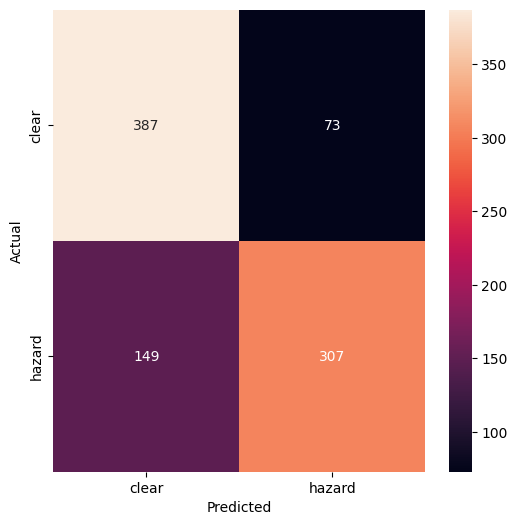

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()